# Deteccion de fraude con tarjeta de credito

Este notebook usa el codigo de `src/` y se detiene en las decisiones que
determinan el resultado.

El dataset es `mlg-ulb/creditcardfraud`, dos dias de operaciones de
tarjetahabientes europeos en septiembre de 2013. Las 28 columnas `V1` a `V28` son
componentes principales calculadas por quienes publicaron los datos, que no
podian liberar las variables originales. Eso limita lo que puede decirse sobre
por que el modelo decide lo que decide.

La pregunta que organiza el trabajo es a que umbral conviene alertar, dado lo que
cuesta revisar una alerta y lo que cuesta bloquear la compra de un cliente que no
hizo nada.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.metrics import average_precision_score
from sklearn.model_selection import train_test_split

from src import (backtest, baselines, config, costs, data, economics,
                 evaluation, features, model)

pd.set_option("display.width", 110)
pd.set_option("display.max_columns", 40)
evaluation.apply_style()

## Los datos

La rareza del evento determina la eleccion de metrica, asi que es lo primero que
hay que medir.

In [2]:
df = data.load_raw()

resumen = pd.Series({
    "Transacciones": len(df),
    "Fraudes": int(df.Class.sum()),
    "Prevalencia (%)": round(df.Class.mean() * 100, 3),
    "Dias cubiertos": round(data.window_days(df.Time), 2),
    "Transacciones por dia": int(len(df) / data.window_days(df.Time)),
    "Monto mediano legitimo": df.loc[df.Class == 0, "Amount"].median(),
    "Monto mediano fraude": df.loc[df.Class == 1, "Amount"].median(),
})
resumen.to_frame("valor")

,valor
Transacciones,284807.000
Fraudes,492.000
Prevalencia (%),0.173
Dias cubiertos,2.000
Transacciones por dia,142410.000
Monto mediano legitimo,22.000
Monto mediano fraude,9.250


Un fraude cada 579 transacciones. Con esa prevalencia un modelo que niegue todo
fraude acierta el 99.83 por ciento de las veces, asi que la exactitud no sirve
como criterio.

La mediana del monto fraudulento queda por debajo de la del monto legitimo. El
fraude tipico de este dataset es pequeno, y eso tiene una consecuencia economica
directa. Bloquear por error una compra legitima puede costar mas que dejar pasar
varios fraudes chicos.

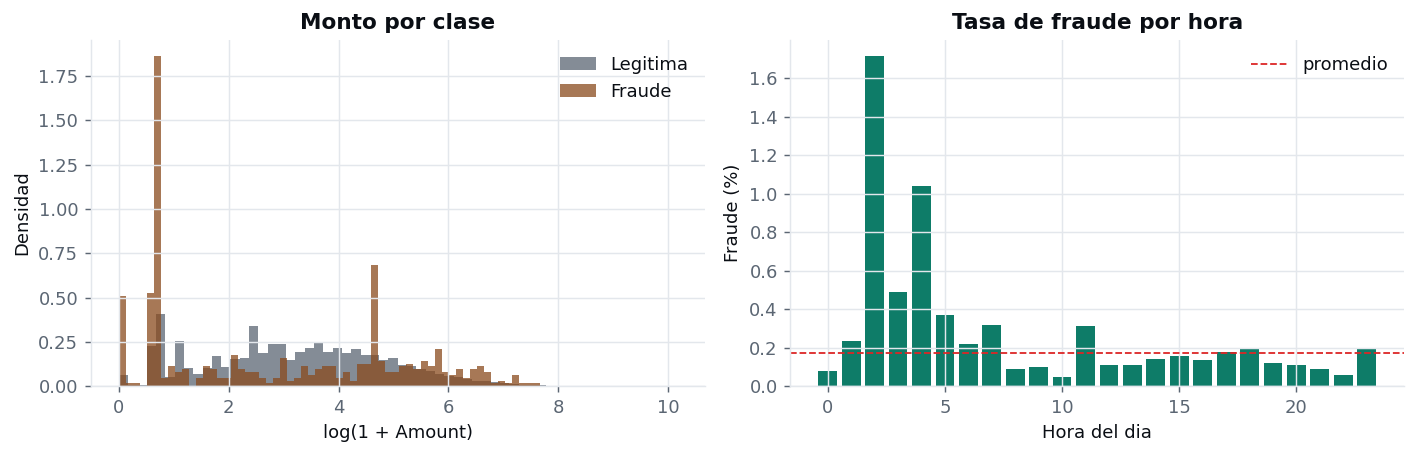

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

for etiqueta, nombre, color in [(0, "Legitima", config.COLOR_MID),
                                (1, "Fraude", config.COLOR_COPPER)]:
    axes[0].hist(np.log1p(df.loc[df.Class == etiqueta, "Amount"]), bins=60,
                 density=True, alpha=0.75, color=color, label=nombre)
axes[0].set(xlabel="log(1 + Amount)", ylabel="Densidad", title="Monto por clase")
axes[0].legend()

hora = (df.Time % 86400) // 3600
tasa = df.groupby(hora).Class.mean() * 100
axes[1].bar(tasa.index, tasa.values, color=config.COLOR_PATINA)
axes[1].axhline(df.Class.mean() * 100, color=config.COLOR_DANGER,
                linestyle="--", linewidth=1, label="promedio")
axes[1].set(xlabel="Hora del dia", ylabel="Fraude (%)", title="Tasa de fraude por hora")
axes[1].legend()

for ax in axes:
    evaluation.clean_axes(ax)
plt.tight_layout()
plt.show()

La hora aporta senal. La madrugada concentra una tasa de fraude varias veces
superior al promedio con mucho menos volumen. Por eso `src/features.py` conserva
la hora del dia y descarta `Time` en bruto. La hora se repite manana. El segundo
145248 no vuelve a existir.

## La particion es temporal

El corte separa pasado de futuro por la columna `Time`. Se entrena con lo
primero y se evalua con lo segundo, que es la forma en que el modelo va a operar.

Los fraudes llegan en rachas, con varias operaciones parecidas sobre la misma
tarjeta comprometida en cuestion de minutos. Un corte al azar reparte esas
operaciones entre los dos conjuntos, de modo que el modelo termina evaluado sobre
casos de los que ya vio un gemelo. La diferencia se puede medir.

In [4]:
X_todo = features.build_features(df)
y_todo = df.Class.astype(int)

# Corte aleatorio estratificado.
Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(
    X_todo, y_todo, test_size=config.TEST_FRACTION,
    random_state=config.RANDOM_STATE, stratify=y_todo)

# Corte temporal, el que usa src/.
train_df, test_df = data.temporal_split(df)
Xt_tr, yt_tr = features.build_features(train_df), train_df.Class.astype(int)
Xt_te, yt_te = features.build_features(test_df), test_df.Class.astype(int)

pipeline = model.candidates(yt_tr)["xgb_weighted"]

ap_aleatorio = average_precision_score(
    ya_te, clone(pipeline).fit(Xa_tr, ya_tr).predict_proba(Xa_te)[:, 1])
ap_temporal = average_precision_score(
    yt_te, clone(pipeline).fit(Xt_tr, yt_tr).predict_proba(Xt_te)[:, 1])

print(f"AP con particion aleatoria : {ap_aleatorio:.4f}")
print(f"AP con particion temporal  : {ap_temporal:.4f}")
print(f"Diferencia                 : {ap_aleatorio - ap_temporal:+.4f}")

AP con particion aleatoria : 0.8761
AP con particion temporal  : 0.7939
Diferencia                 : +0.0821


Esa brecha es optimismo. No es grande, y por eso mismo pasa desapercibida y se
propaga a cualquier promesa que se haga sobre el desempeno futuro.

## El conjunto de prueba entra completo

Un filtro de rango intercuartilico sobre el conjunto de prueba lo vuelve mas
facil de lo que sera la realidad, por dos razones.

El fraude vive en la cola. Las componentes principales de una operacion
fraudulenta se apartan del centro mucho mas que las de una legitima, asi que un
filtro de atipicos elimina sobre todo fraudes. Y en produccion nadie puede
descartar una transaccion por ser rara antes de decidir si la aprueba.

El tamano del efecto se puede cuantificar.

In [5]:
def filtro_iqr(X, y, k=1.15, max_violaciones=2):
    """Filtro de atipicos por clase, para medir que se lleva."""
    violaciones = pd.Series(0, index=X.index)
    for clase in (0, 1):
        idx = y == clase
        bloque = X.loc[idx]
        conteo = pd.Series(0, index=bloque.index)
        for col in bloque.columns:
            q1, q3 = bloque[col].quantile([0.25, 0.75])
            rango = q3 - q1
            conteo += ~bloque[col].between(q1 - k * rango, q3 + k * rango)
        violaciones.loc[idx] = conteo
    conservar = violaciones <= max_violaciones
    return X.loc[conservar], y.loc[conservar]

Xf_te, yf_te = filtro_iqr(Xt_te, yt_te)

comparacion = pd.DataFrame({
    "Prueba completa": [len(yt_te), int(yt_te.sum())],
    "Prueba filtrada": [len(yf_te), int(yf_te.sum())],
}, index=["Transacciones", "Fraudes"])
comparacion["Se descarta (%)"] = (
    (1 - comparacion["Prueba filtrada"] / comparacion["Prueba completa"]) * 100).round(1)
comparacion

,Prueba completa,Prueba filtrada,Se descarta (%)
Transacciones,56962,41967,26.3
Fraudes,75,60,20.0


In [6]:
modelo_demo = clone(pipeline).fit(Xt_tr, yt_tr)

ap_completo = average_precision_score(yt_te, modelo_demo.predict_proba(Xt_te)[:, 1])
ap_filtrado = average_precision_score(yf_te, modelo_demo.predict_proba(Xf_te)[:, 1])

print(f"AP sobre la prueba completa : {ap_completo:.4f}")
print(f"AP sobre la prueba filtrada : {ap_filtrado:.4f}")
print(f"Inflacion                   : {ap_filtrado - ap_completo:+.4f}")

AP sobre la prueba completa : 0.7939
AP sobre la prueba filtrada : 0.8458
Inflacion                   : +0.0519


Ninguna de las dos cifras esta mal calculada. La diferencia esta en sobre que
poblacion se calcula, y esa eleccion se hace antes de escribir la metrica.

De aqui en adelante el conjunto de prueba no se toca.

## La vara a superar

Un emisor sin modelo estadistico no aprueba todo. Opera un motor de reglas
escritas y calibradas por analistas, asi que la comparacion honesta es contra ese
motor. Medir contra la ausencia de control mide el valor de tener cualquier
control, no el valor del modelo.

Tres reglas, calibradas sobre el mismo tramo de validacion que usa el umbral del
modelo.

In [7]:
corte_b = int(len(train_df) * (1 - config.VALIDATION_FRACTION))
ajuste_b = train_df.iloc[:corte_b]
val_b = train_df.iloc[corte_b:].reset_index(drop=True)

Xa_b, ya_b = features.build_features(ajuste_b), ajuste_b.Class.astype(int)
Xv_b, yv_b = features.build_features(val_b), val_b.Class.astype(int)
Av_b, dv_b = val_b.Amount.to_numpy(), data.window_days(val_b.Time)

arbol = baselines.fit_rule_engine(Xa_b, ya_b)
calibracion = baselines.calibrate(Xv_b, yv_b, Av_b, val_b.Time, dv_b, tree=arbol)

pd.DataFrame([{
    "regla": k,
    "descripcion": v["descripcion"],
    "ahorro": round(v["savings_share"], 3),
    "recall": v["recall"],
    "alertas/dia": v["alerts_per_day"],
} for k, v in calibracion.items()]).set_index("regla")

,descripcion,ahorro,recall,alertas/dia
regla,,,,
monto,revisar si Amount >= 2499.91,-0.253,0.0000,396.3
monto_hora,"revisar si Amount >= 1814.92, o si Amount >= 7...",-0.364,0.0175,792.7
arbol,"motor de reglas de profundidad 3, 8 hojas, umb...",0.345,0.7193,403.3


Las dos reglas de monto destruyen valor. La mediana del fraude de este dataset es
de 9,25 unidades, de modo que un corte por monto alto cobra friccion sobre compras
grandes legitimas sin interceptar casi nada.

El motor de reglas de profundidad tres es la vara relevante, y se lee como una
lista de condiciones.

In [8]:
print(baselines.rule_engine_text(arbol, features.FEATURE_COLUMNS))

|--- V14 <= -1.63
|   |--- V10 <= -1.88
|   |   |--- V11 <= 0.13
|   |   |   |--- class: 0
|   |   |--- V11 >  0.13
|   |   |   |--- class: 1
|   |--- V10 >  -1.88
|   |   |--- V4 <= 2.27
|   |   |   |--- class: 0
|   |   |--- V4 >  2.27
|   |   |   |--- class: 1
|--- V14 >  -1.63
|   |--- V4 <= 1.66
|   |   |--- V14 <= -0.43
|   |   |   |--- class: 0
|   |   |--- V14 >  -0.43
|   |   |   |--- class: 0
|   |--- V4 >  1.66
|   |   |--- V8 <= -0.11
|   |   |   |--- class: 1
|   |   |--- V8 >  -0.11
|   |   |   |--- class: 0



Ese motor corta sobre componentes principales anonimizadas, que un analista no
podria escribir a mano. En este dataset cualquier linea base creible ya tiene que
derivarse de los datos, porque las dos unicas variables interpretables que hay,
monto y hora, no alcanzan para una regla que no pierda dinero.

## La funcion de perdida declara que le importa al banco

El costo de un error depende del monto. Dejar pasar un fraude de 2000 cuesta
doscientas veces mas que dejar pasar uno de 10, y una perdida que trate a los dos
como el mismo evento entrena para el problema equivocado.

`src/costs.py` implementa la reduccion de clasificacion sensible al costo a
clasificacion ponderada. A cada observacion se le asigna el arrepentimiento de
decidir mal sobre ella, y minimizar la log loss ponderada por ese peso equivale a
minimizar el costo esperado.

Hay un detalle que decide si el esquema funciona. Los pesos crudos corrigen la
asimetria de costo pero no la de frecuencia, y con un fraude cada 579 operaciones
el peso medio del fraude queda muy por debajo de lo que necesita para pesar en el
gradiente.

In [9]:
y_fit_demo = train_df.Class.astype(int).to_numpy()
A_demo = train_df.Amount.to_numpy()

tabla = []
for esquema in ("linear", "balanced"):
    w = costs.regret_weights(y_fit_demo, A_demo, amount_cap=config.AMOUNT_CAP,
                             scheme=esquema)
    tabla.append({
        "esquema": esquema,
        "peso legitima": w[y_fit_demo == 0][0],
        "peso medio fraude": round(w[y_fit_demo == 1].mean(), 1),
        "razon de peso total": round(w[y_fit_demo == 1].sum() / w[y_fit_demo == 0].sum(), 3),
        "equivale a spw": round(w[y_fit_demo == 1].mean() / w[y_fit_demo == 0][0], 1),
    })
print(f"Negativos por cada positivo: {model.imbalance_ratio(y_fit_demo):.1f}")
pd.DataFrame(tabla).set_index("esquema")

Negativos por cada positivo: 545.4


,peso legitima,peso medio fraude,razon de peso total,equivale a spw
esquema,,,,
linear,29.0,110.4,0.007,3.8
balanced,29.0,15816.3,1.000,545.4


El esquema `balanced` reescala los pesos del fraude para que el total de las dos
clases se iguale. Conserva la diferenciacion por monto dentro de los fraudes y
recupera el balanceo entre clases.

## Comparacion de perdidas

Cinco candidatos, cada uno definido por la penalidad con que se entrena. El
criterio es el ahorro esperado en el punto de operacion.

Cada candidato se evalua recorriendo la historia en tramos sucesivos. En cada tramo
se entrena con el pasado, se fija el umbral con la parte final de ese pasado y se
mide el ahorro sobre el tramo siguiente, de modo que la cifra no hereda el
optimismo de elegir el umbral y medirlo sobre los mismos datos.

La referencia lineal cumple una funcion concreta. Las componentes principales ya
separan bastante las dos clases, asi que sin una vara lineal no se puede saber
cuanta de la separacion aporta el modelo.

In [10]:
A_tr = train_df.Amount.astype(float)
T_tr = train_df.Time.astype(float)

nombre_elegido, resultados = model.select_candidate(Xt_tr, yt_tr, A_tr, T_tr)

tabla = pd.DataFrame(resultados).T[
    ["savings_share_mean", "savings_share_std", "value_recall_mean",
     "alerts_per_day_mean"]]
tabla.columns = ["Ahorro", "Desviacion", "Monto interceptado", "Alertas/dia"]
tabla.sort_values("Ahorro", ascending=False)

,Ahorro,Desviacion,Monto interceptado,Alertas/dia
xgb_weighted,0.5706,0.0776,0.7241,216.3
xgb_cost_balanced,0.5563,0.0736,0.7061,213.8
xgb_plain,0.5494,0.0975,0.6893,179.9
xgb_cost,0.4532,0.0956,0.5833,194.7
logreg_balanced,0.382,0.0616,0.6914,456.5


Las tres columnas de la derecha son las que un area de riesgo puede firmar. El
ahorro resume la decision, el monto interceptado dice cuanto dinero se frena y las
alertas por dia dicen si el equipo puede sostenerlo.

La desviacion importa tanto como el ahorro. La distancia entre las dos primeras
perdidas es menor que su dispersion entre folds, asi que con esta muestra son
indistinguibles.

La referencia lineal muestra por que hace falta mirar mas de una columna.
Intercepta casi tanto monto como el ganador y sin embargo ahorra veinte puntos
menos, porque genera mas del doble de alertas y eso se paga en revision y en
friccion.

El area bajo la curva de precision y recall queda en `reports/metrics.json` para
comparar con la literatura del dataset, pero no entra en esta tabla.

## El umbral se decide con dinero

Un score de 0.5 no tiene nada de especial. El umbral correcto minimiza el costo
esperado sujeto a la capacidad de revision declarada.

Los supuestos viven en `src/config.py`. El costo de friccion es el mas incierto,
porque nadie publica lo que cuesta bloquear la compra de un cliente que no hizo
nada.

El umbral se fija sobre un tramo de validacion que sale del pasado.

In [11]:
import joblib

corte = int(len(train_df) * (1 - config.VALIDATION_FRACTION))
ajuste_df = train_df.iloc[:corte].reset_index(drop=True)
val_df = train_df.iloc[corte:].reset_index(drop=True)

# El pipeline afinado lo dejo `python -m src.train`. `clone` devuelve una copia
# sin ajustar que conserva los hiperparametros, asi que se puede reentrenar
# sobre el tramo que corresponda en cada paso.
afinado = clone(joblib.load(config.MODEL_PATH)["pipeline"])

modelo_umbral = clone(afinado).fit(
    features.build_features(ajuste_df), ajuste_df.Class.astype(int))

score_val = modelo_umbral.predict_proba(features.build_features(val_df))[:, 1]
y_val = val_df.Class.astype(int)
monto_val = val_df.Amount.to_numpy()
dias_val = data.window_days(val_df.Time)

curva = economics.cost_curve(y_val, score_val, monto_val, dias_val,
                             thresholds=[0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 0.94, 0.98])
elegido = economics.pick_threshold(y_val, score_val, monto_val, dias_val)

pd.DataFrame([{
    "Umbral": c.threshold,
    "Recall": c.recall,
    "Precision": c.precision,
    "Alertas/dia": c.alerts_per_day,
    "Costo total": round(c.total_cost),
    "Ahorro": round(c.savings),
} for c in curva]).set_index("Umbral")

,Recall,Precision,Alertas/dia,Costo total,Ahorro
Umbral,,,,,
0.05,0.7895,0.4737,330.3,7447,5639
0.10,0.7719,0.5789,264.2,6937,6149
0.20,0.7544,0.6232,239.9,6774,6312
0.30,0.7544,0.6825,219.0,6600,6486
0.50,0.7544,0.7818,191.2,6368,6718
0.70,0.7544,0.8431,177.3,6252,6834
0.90,0.7544,0.8776,170.4,6194,6892
0.94,0.7544,0.8958,166.9,6165,6921
0.98,0.7544,0.9348,159.9,6107,6979


In [12]:
print(f"Umbral elegido en validacion: {elegido.threshold}")
print(f"Recall {elegido.recall:.3f} | precision {elegido.precision:.3f} | "
      f"{elegido.alerts_per_day:.0f} alertas por dia")

Umbral elegido en validacion: 0.96
Recall 0.754 | precision 0.935 | 160 alertas por dia


El optimo queda muy por encima del 0.5 por omision. La razon esta en la forma de
la distribucion del score.

In [13]:
scores_fraude = np.sort(score_val[y_val == 1])
tramos = pd.Series({
    "score < 0.01": int((scores_fraude < 0.01).sum()),
    "0.01 a 0.95": int(((scores_fraude >= 0.01) & (scores_fraude < 0.95)).sum()),
    "score >= 0.95": int((scores_fraude >= 0.95).sum()),
})
print(f"Distribucion del score entre los {int(y_val.sum())} fraudes de validacion:")
print(tramos.to_string())

techo = economics.unreachable_fraud(y_val, score_val, monto_val)
print(f"\nFraudes con score casi nulo: {techo['frauds_below_floor']} "
      f"({techo['share_of_frauds']:.0%} de los fraudes)")
print(f"Monto que representan: {techo['amount_below_floor']:,.0f} "
      f"({techo['share_of_fraud_amount']:.0%} del monto fraudulento total)")

Distribucion del score entre los 57 fraudes de validacion:
score < 0.01     11
0.01 a 0.95       3
score >= 0.95    43

Fraudes con score casi nulo: 11 (19% de los fraudes)
Monto que representan: 4,470 (37% del monto fraudulento total)


El score es casi binario. La mayoria de los fraudes recibe un valor por encima de
0.95 y un grupo pequeno recibe practicamente cero, con unos pocos en la zona
intermedia. Mover el umbral entre 0.05 y 0.94 casi no cambia cuantos fraudes se
detectan, y si cambia mucho cuantas transacciones legitimas se bloquean.

Los fraudes que el modelo no ve no se recuperan bajando el umbral, porque su
score no esta cerca de ninguna frontera razonable. Concentran cerca de un tercio
del monto fraudulento de la ventana y marcan el techo del proyecto.

## Medicion final

Una sola vez, contra el futuro, con el umbral congelado.

In [14]:
modelo_final = clone(afinado).fit(Xt_tr, yt_tr)
score_test = modelo_final.predict_proba(Xt_te)[:, 1]
monto_test = test_df.Amount.to_numpy()
dias_test = data.window_days(test_df.Time)

ranking = evaluation.ranking_metrics(yt_te, score_test)
costo_test = economics.cost_at_threshold(
    yt_te, score_test, monto_test, elegido.threshold, dias_test)

pd.Series({
    "Average precision": ranking["average_precision"],
    "Veces mejor que el azar": ranking["ap_lift_over_baseline"],
    "ROC AUC": ranking["roc_auc"],
    "Recall al umbral": costo_test.recall,
    "Precision al umbral": costo_test.precision,
    "Alertas por dia": costo_test.alerts_per_day,
    "Fraudes detectados": costo_test.true_positives,
    "Fraudes no detectados": costo_test.false_negatives,
    "Legitimas bloqueadas": costo_test.false_positives,
}).to_frame("valor")

,valor
Average precision,0.8099
Veces mejor que el azar,615.1000
ROC AUC,0.9848
Recall al umbral,0.7333
Precision al umbral,0.9483
Alertas por dia,181.9000
Fraudes detectados,55.0000
Fraudes no detectados,20.0000
Legitimas bloqueadas,3.0000


El ROC AUC pasa de 0.98 y dice poco. Con unos 760 negativos por cada positivo,
ordenar bien los negativos entre si es gratis y el AUC premia eso.

In [15]:
desglose = pd.Series({
    "Fraude no detectado": costo_test.cost_missed_fraud,
    "Fraude no recuperado": costo_test.cost_unrecovered_fraud,
    "Revision de alertas": costo_test.cost_review,
    "Bloqueos a clientes legitimos": costo_test.cost_friction,
    "Costo total con el modelo": costo_test.total_cost,
})
print(f"Ventana de prueba: {dias_test:.2f} dias, {len(yt_te):,} transacciones")
desglose.to_frame("unidades monetarias")

Ventana de prueba: 0.32 dias, 56,962 transacciones


,unidades monetarias
Fraude no detectado,2979.17
Fraude no recuperado,757.51
Revision de alertas,232.00
Bloqueos a clientes legitimos,75.00
Costo total con el modelo,4043.68


Para saber cuanto se ahorra hay que decir frente a que. Aprobar todo sin ningun
control es el techo teorico de la perdida, no una alternativa que alguien opere. La
comparacion relevante es contra el motor de reglas, que es lo que la entidad gasta
hoy.

In [16]:
score_reglas_test = baselines.apply(
    "arbol", calibracion["arbol"]["parametros"], Xt_te, monto_test,
    test_df.Time, tree=arbol)
costo_reglas = economics.cost_at_threshold(
    yt_te, score_reglas_test, monto_test,
    calibracion["arbol"]["parametros"]["threshold"], dias_test)

incremental = costo_reglas.total_cost - costo_test.total_cost

pd.Series({
    "Aprobar todo sin control": costo_test.baseline_cost,
    "Motor de reglas, el costo de hoy": costo_reglas.total_cost,
    "Modelo": costo_test.total_cost,
    "Ahorro frente al costo actual": incremental,
    "Reduccion del costo actual (%)": round(incremental / costo_reglas.total_cost * 100, 1),
}).to_frame("unidades monetarias")

,unidades monetarias
Aprobar todo sin control,8854.26
"Motor de reglas, el costo de hoy",7065.24
Modelo,4043.68
Ahorro frente al costo actual,3021.56
Reduccion del costo actual (%),42.80


La penultima fila es el caso de negocio. Reemplazar el motor de reglas por el
modelo reduce en algo mas de cuarenta por ciento lo que la entidad gasta hoy por
fraude, contando tanto el dinero perdido como el costo de operar la revision.

Estas cifras corresponden a la ventana de prueba. Son unas siete horas de operacion
de un emisor europeo en 2013, sobre montos en una unidad que el publicador del
dataset no documento. La proporcion se puede trasladar. El monto absoluto no.

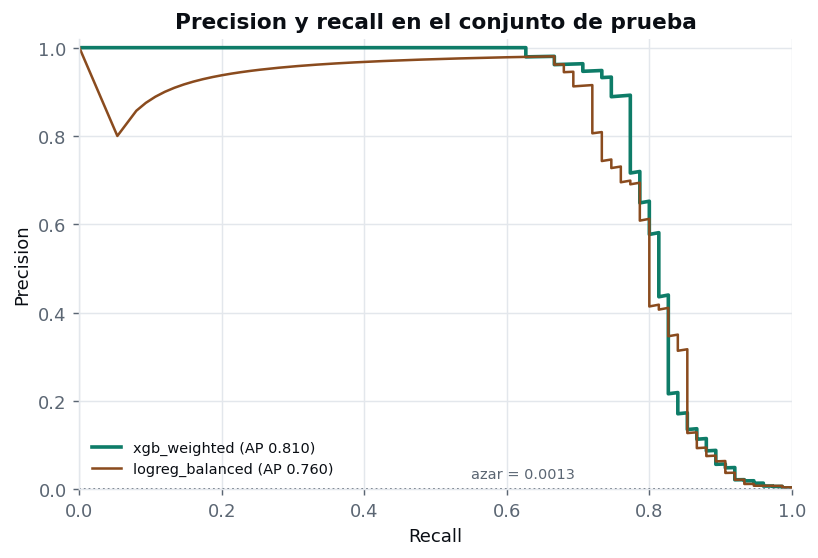

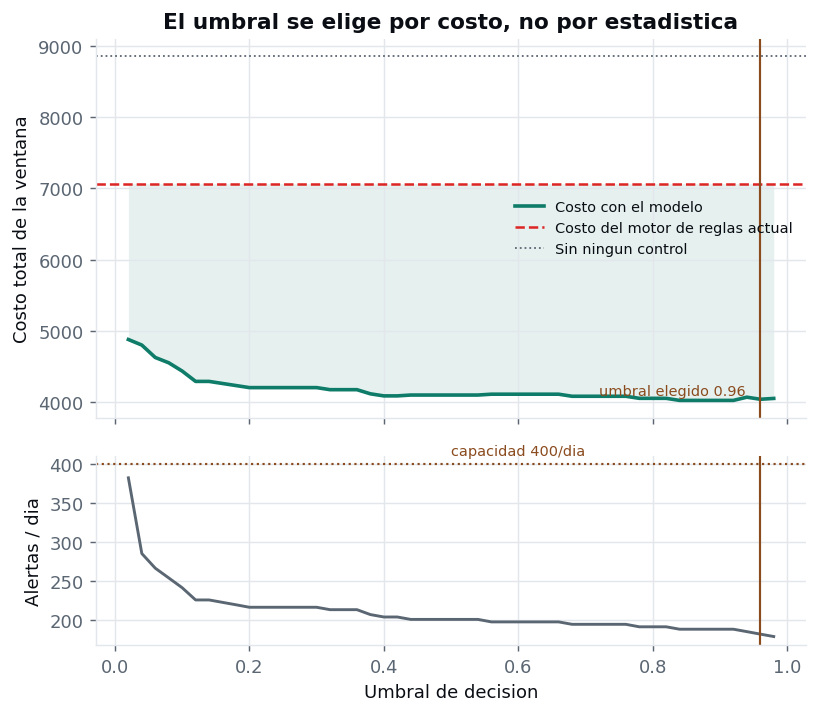

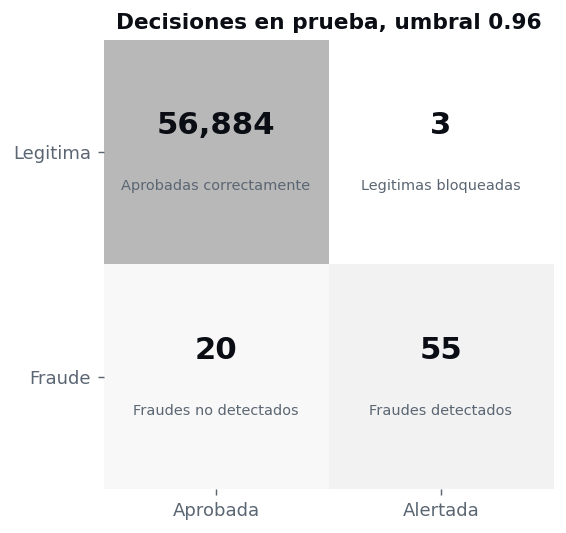

In [17]:
from IPython.display import Image, display

for archivo in ("pr-curve.png", "cost-vs-threshold.png", "confusion.png"):
    display(Image(str(config.FIGURES_DIR / archivo)))

## Backtesting

La comparacion de perdidas promedia varios tramos y devuelve un solo numero por
candidato, que alcanza para ordenarlos. Para saber si el resultado se sostiene hace
falta ver los tramos por separado.

El backtest recorre la linea de tiempo hacia adelante y en cada paso hace lo que
haria la operacion. Reentrena con toda la historia disponible, recalibra el umbral
con el tramo mas reciente de ese pasado, y decide sobre el periodo siguiente sin
volver a mirarlo.

In [18]:
resumen_bt = backtest.walk_forward(df, clone(afinado), n_blocks=6)

tabla_bt = pd.DataFrame(resumen_bt["blocks"])[
    ["block", "block_frauds", "threshold", "recall", "savings_share",
     "rule_savings_share", "uplift_points"]].set_index("block")
print(f"Ahorro medio {resumen_bt['savings_share_mean']:.1%} "
      f"| desviacion {resumen_bt['savings_share_std']:.1%} "
      f"| rango {resumen_bt['savings_share_min']:.1%} a {resumen_bt['savings_share_max']:.1%}")
print(f"El modelo gana en {resumen_bt['blocks_where_model_wins']} de "
      f"{resumen_bt['n_blocks_evaluated']} bloques")
tabla_bt

Ahorro medio 49.2% | desviacion 18.4% | rango 16.9% a 79.2%
El modelo gana en 6 de 6 bloques


,block_frauds,threshold,recall,savings_share,rule_savings_share,uplift_points
block,,,,,,
1,74,0.98,0.8108,0.5458,-0.1591,70.5
2,30,0.26,0.8000,0.1692,-2.3256,249.5
3,29,0.98,0.7586,0.5100,-0.2931,80.3
4,29,0.94,0.7241,0.7917,-0.3780,117.0
5,49,0.98,0.7755,0.4146,0.2450,17.0
6,21,0.72,0.7143,0.5221,0.2501,27.2


La dispersion es el resultado que importa. Un modelo que ahorra 47 por ciento de
promedio con bloques de 24 y de 71 no es el mismo producto que uno que ahorra 45
en todos, y esa diferencia no aparece en ninguna medicion de un solo corte.

El umbral recalibrado tambien se mueve entre bloques, lo que indica que la
recalibracion periodica no es opcional.

Con dos dias de datos los bloques son de horas y traen entre 21 y 74 fraudes. El
procedimiento es el que corresponde y la evidencia es indicativa. Un backtest util
necesita meses.

## Que se le puede exigir al modelo

En una operacion real la capacidad de revision, la precision minima que tolera el
equipo y el piso de monto que exige riesgo vienen dados. Cada restriccion mueve
el punto de operacion y tiene un precio.

In [19]:
envolvente = economics.operating_envelope(
    yt_te, score_test, monto_test, dias_test)

cap = pd.DataFrame(envolvente["by_daily_capacity"]).T
cap.index.name = "alertas/dia"
print(f"Techo de recall de valor: {envolvente['max_value_recall_while_profitable']:.1%}\n")
cap[["precision", "recall", "value_recall", "savings", "share_of_unconstrained"]]

Techo de recall de valor: 77.3%



,precision,recall,value_recall,savings,share_of_unconstrained
alertas/dia,,,,,
25,1.0000,0.1067,0.0647,513.38,0.1067
50,1.0000,0.2133,0.1708,1297.88,0.2698
100,1.0000,0.4267,0.4246,3141.29,0.6530
150,0.9792,0.6267,0.4863,3682.97,0.7656
200,0.8906,0.7600,0.6587,4751.34,0.9877
400,0.4766,0.8133,0.7718,3798.90,0.7897
800,0.2431,0.8267,0.7734,166.37,0.0346


In [20]:
prec = pd.DataFrame(
    {k: v for k, v in envolvente["by_min_precision"].items() if v}).T
prec.index.name = "precision minima"
prec[["threshold", "recall", "value_recall", "alerts_per_day",
      "savings", "share_of_unconstrained"]]

,threshold,recall,value_recall,alerts_per_day,savings,share_of_unconstrained
precision minima,,,,,,
0.5,0.9758,0.7333,0.6534,181.9,4810.58,1.0000
0.75,0.9758,0.7333,0.6534,181.9,4810.58,1.0000
0.9,0.9758,0.7333,0.6534,181.9,4810.58,1.0000
0.95,0.9998,0.5867,0.4850,138.0,3670.11,0.7629
0.99,0.9998,0.5867,0.4850,138.0,3670.11,0.7629


La capacidad tiene optimo interior. Por debajo de cierto presupuesto la
restriccion muerde, y por encima el sistema se degrada porque se paga revision y
friccion por alertas que en su mayoria son falsas.

El techo de recall de valor es el numero que conviene llevar a una conversacion
con riesgo. Fija cuanto del monto fraudulento se puede interceptar con estos
datos, y ninguna eleccion de umbral lo mueve.

## Sensibilidad de los supuestos

El costo de friccion se eligio a mano. Antes de defender el umbral conviene ver
en que rango ese supuesto cambia la decision.

In [21]:
pd.DataFrame(economics.sensitivity(
    y_val, score_val, monto_val, dias_val,
    "friction", [0, 5, 10, 25, 50, 100])).set_index("friction")

,threshold,recall,precision,alerts_per_day,savings,savings_share
friction,,,,,,
0,0.96,0.7544,0.9348,159.9,7053.8,0.5390
5,0.96,0.7544,0.9348,159.9,7038.8,0.5379
10,0.96,0.7544,0.9348,159.9,7023.8,0.5367
25,0.96,0.7544,0.9348,159.9,6978.8,0.5333
50,0.96,0.7544,0.9348,159.9,6903.8,0.5276
100,0.96,0.7544,0.9348,159.9,6753.8,0.5161


In [22]:
pd.DataFrame(economics.sensitivity(
    y_val, score_val, monto_val, dias_val,
    "review", [0, 0.5, 1, 2, 4, 8])).set_index("review")

,threshold,recall,precision,alerts_per_day,savings,savings_share
review,,,,,,
0.0,0.96,0.7544,0.9348,159.9,7162.8,0.5474
0.5,0.96,0.7544,0.9348,159.9,7139.8,0.5456
1.0,0.96,0.7544,0.9348,159.9,7116.8,0.5438
2.0,0.96,0.7544,0.9348,159.9,7070.8,0.5403
4.0,0.96,0.7544,0.9348,159.9,6978.8,0.5333
8.0,0.96,0.7544,0.9348,159.9,6794.8,0.5192


Cada barrido por separado sale plano. Como no pueden ser los dos irrelevantes a
la vez, hay que moverlos en conjunto.

In [23]:
rejilla = pd.DataFrame(economics.sensitivity_grid(
    y_val, score_val, monto_val, dias_val,
    {"review": [0, 1, 2, 4], "friction": [0, 2, 5, 10, 25]}))

print("Umbral elegido segun los dos supuestos:")
print(rejilla.pivot(index="review", columns="friction", values="threshold").to_string())
print("\nRecall resultante:")
print(rejilla.pivot(index="review", columns="friction", values="recall").to_string())

Umbral elegido segun los dos supuestos:
friction    0     2     5     10    25
review                                
0         0.04  0.96  0.96  0.96  0.96
1         0.96  0.96  0.96  0.96  0.96
2         0.96  0.96  0.96  0.96  0.96
4         0.96  0.96  0.96  0.96  0.96

Recall resultante:
friction      0       2       5       10      25
review                                          
0         0.7895  0.7544  0.7544  0.7544  0.7544
1         0.7544  0.7544  0.7544  0.7544  0.7544
2         0.7544  0.7544  0.7544  0.7544  0.7544
4         0.7544  0.7544  0.7544  0.7544  0.7544


El umbral solo cede en la esquina donde revisar una alerta es casi gratis y
ademas bloquear a un cliente inocente no cuesta nada. Fuera de esa esquina, que
no describe ninguna operacion real, la respuesta es la misma en todo el rango
probado.

La decision no depende del supuesto mas discutible del ejercicio, y ahi tambien
esta la senal de donde no vale la pena seguir trabajando. Afinar los costos no va
a cambiar el resultado.

## Limites

Las variables son componentes principales anonimizadas, asi que no hay forma de
explicarle a un analista de riesgo por que se alerto una operacion. Sin eso una
cola de revision no se opera.

No hay identificador de tarjeta ni de comercio, y esa ausencia fija el techo. Las
senales que mas usan los sistemas reales son agregados sobre la historia de cada
tarjeta. Cuantas compras lleva en la ultima hora, cuanto se aparta el monto de su
promedio habitual, si el pais cambio respecto a la operacion anterior. Ninguna se
puede construir sin esa llave, y son justamente las que reconocerian a los
fraudes que aqui reciben score cero.

Son dos dias de 2013. El fraude cambia de forma cuando cambian los controles, de
modo que un modelo entrenado aqui no dice nada sobre el fraude de hoy. Lo que
sobrevive es el procedimiento.

Quedan 75 fraudes en el conjunto de prueba. Con esa cantidad el intervalo de
confianza del recall es ancho y cualquier diferencia de un punto entre dos
modelos cae dentro del ruido.